# Does wind speed predict Ireland's renewable share?

Reads the gold dataset `02_transformations.ipynb` wrote to `data/processed/weather_generation_merged.csv` - hourly Dublin weather joined against hourly-resampled Irish generation data.

Ireland's renewable generation isn't only wind - the pipeline's own `RENEWABLE_SOURCES` set also includes Solar, Hydro, Biomass, and others - so a weak correlation with radiation later in this notebook wouldn't mean "solar doesn't count," only that solar's installed capacity is small next to wind's in the ENTSO-E mix this pipeline ingests. Let the coefficients say what they say rather than assuming the answer going in.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

merged = pd.read_csv(
    Path("../data/processed/weather_generation_merged.csv"), index_col="timestamp", parse_dates=True
)
print(f"{len(merged)} hourly rows")
merged.head()

Matplotlib is building the font cache; this may take a moment.


25 hourly rows


,renewable_pct,total_generation_mw,renewable_mw,temperature_2m,wind_speed_10m,shortwave_radiation
timestamp,,,,,,
2026-08-14 15:00:00+00:00,38.253333,1482.0,567.0,8.0,15.0,0.0
2026-08-14 16:00:00+00:00,39.295000,1594.0,626.5,8.5,18.0,0.0
2026-08-14 17:00:00+00:00,40.620000,1709.5,694.5,9.0,21.0,0.0
2026-08-14 18:00:00+00:00,42.357500,1800.0,762.5,9.5,24.0,40.0
2026-08-14 19:00:00+00:00,42.172500,1898.0,800.5,10.0,27.0,80.0


In [2]:
# Chart chrome, kept as plain constants rather than a separate config file -
# this is the only notebook that plots anything, so there's nothing else to
# share these with.
COLOR_BG = "#fcfcfb"
COLOR_INK = "#0b0b0b"
COLOR_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_BLUE = "#2a78d6"
COLOR_ORANGE = "#eb6834"

plt.rcParams.update(
    {
        "figure.facecolor": COLOR_BG,
        "axes.facecolor": COLOR_BG,
        "axes.edgecolor": COLOR_MUTED,
        "axes.labelcolor": COLOR_SECONDARY,
        "text.color": COLOR_INK,
        "xtick.color": COLOR_MUTED,
        "ytick.color": COLOR_MUTED,
        "grid.color": COLOR_GRID,
        "grid.linewidth": 0.8,
        "font.family": "sans-serif",
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## Wind speed vs. renewable share

A scatter, not a dual-axis chart - overlaying two different-scale measures on twin y-axes invents visual correlation that isn't necessarily in the data (the alignment of the two scales is arbitrary). A scatter of one against the other, with a fitted line and the actual correlation coefficient, says only what the data says.

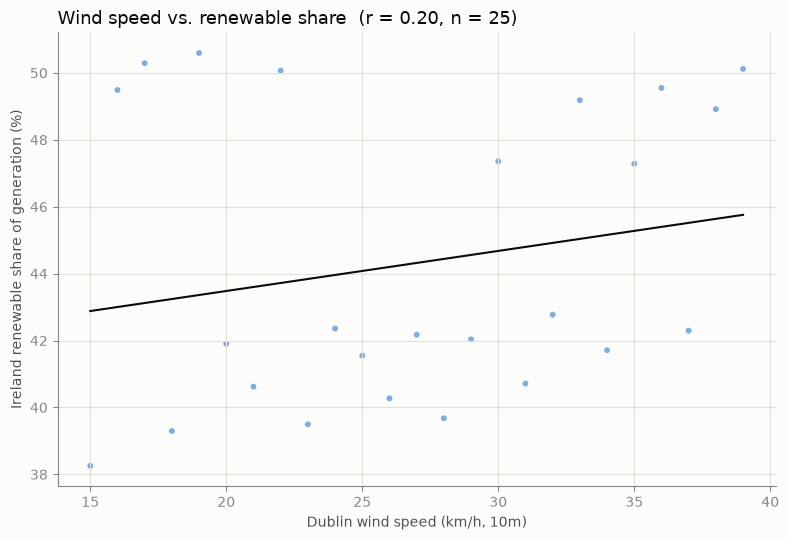

In [3]:
x = merged["wind_speed_10m"]
y = merged["renewable_pct"]
corr = x.corr(y)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(x, y, s=18, color=COLOR_BLUE, alpha=0.6, edgecolors="none")

if len(x) > 1:
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color=COLOR_INK, linewidth=1.5)

ax.set_xlabel("Dublin wind speed (km/h, 10m)")
ax.set_ylabel("Ireland renewable share of generation (%)")
ax.set_title(f"Wind speed vs. renewable share  (r = {corr:.2f}, n = {len(x)})", loc="left", fontsize=13)
fig.tight_layout()
plt.show()

## The same story, over time

Two stacked panels sharing one x-axis, not one panel with two y-axes - same reasoning as above, just for a time series instead of a scatter. If the two lines visually track each other, that's the relationship showing up honestly rather than being manufactured by an arbitrary scale choice.

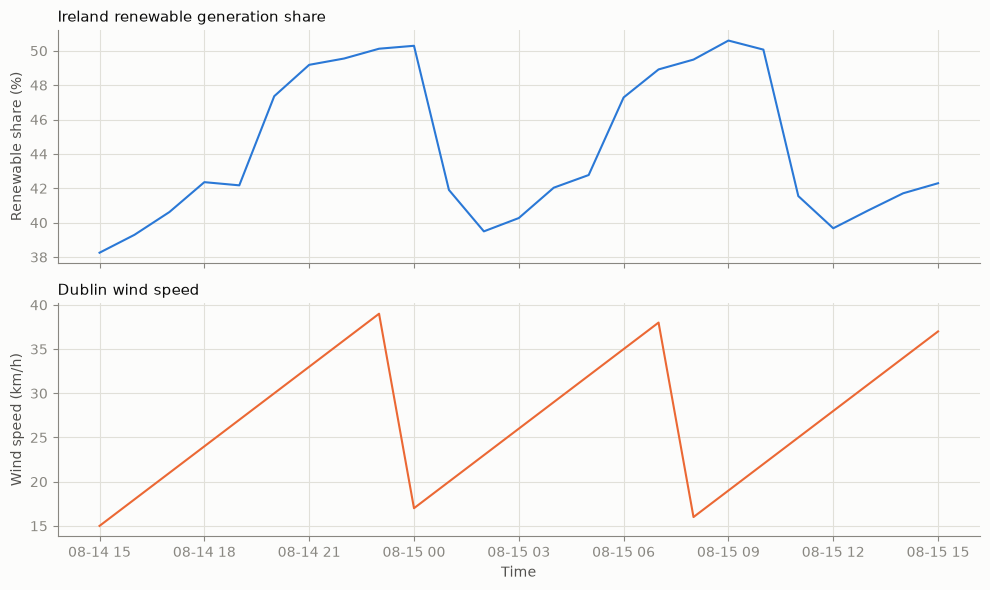

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(merged.index, merged["renewable_pct"], color=COLOR_BLUE, linewidth=1.5)
axes[0].set_ylabel("Renewable share (%)")
axes[0].set_title("Ireland renewable generation share", loc="left", fontsize=11)

axes[1].plot(merged.index, merged["wind_speed_10m"], color=COLOR_ORANGE, linewidth=1.5)
axes[1].set_ylabel("Wind speed (km/h)")
axes[1].set_title("Dublin wind speed", loc="left", fontsize=11)
axes[1].set_xlabel("Time")

fig.tight_layout()
plt.show()

## What about solar?

Same scatter treatment against shortwave radiation, for comparison.

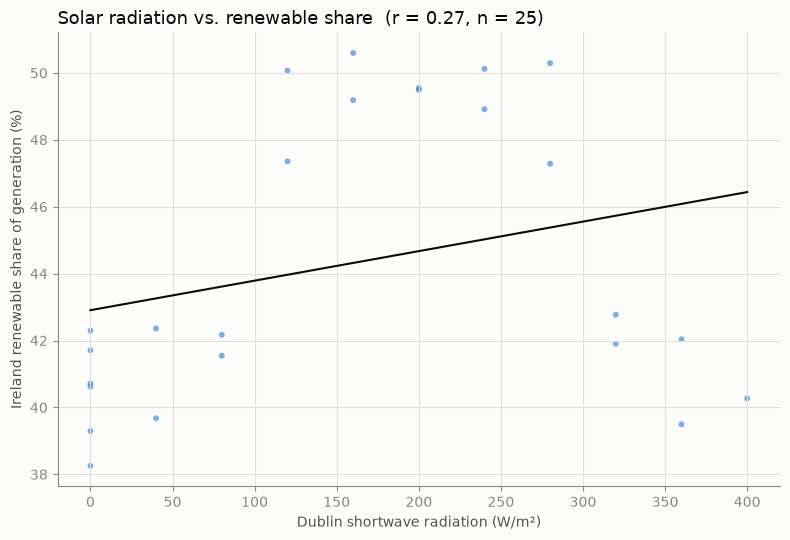

In [5]:
x2 = merged["shortwave_radiation"]
corr2 = x2.corr(y)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(x2, y, s=18, color=COLOR_BLUE, alpha=0.6, edgecolors="none")

if len(x2) > 1:
    slope, intercept = np.polyfit(x2, y, 1)
    x_line = np.linspace(x2.min(), x2.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color=COLOR_INK, linewidth=1.5)

ax.set_xlabel("Dublin shortwave radiation (W/m\u00b2)")
ax.set_ylabel("Ireland renewable share of generation (%)")
ax.set_title(f"Solar radiation vs. renewable share  (r = {corr2:.2f}, n = {len(x2)})", loc="left", fontsize=13)
fig.tight_layout()
plt.show()

## Caveat

The scheduled workflow only started running live recently, so `n` above is still small - these coefficients will keep sharpening as more 6-hourly runs land in `raw_ingestions` and `generation_summary`, with nothing in this notebook needing to change to pick that up. Re-run `02_transformations.ipynb` then this notebook at any point to refresh the numbers and charts against the latest data.